Workshop 1 - Sampling

In [3]:
import math
import torch
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)

# ----------------------------
# plotting
# ----------------------------
def hist_plot(x, title, bins=60):
    plt.figure()
    plt.hist(x.detach().cpu().numpy(), bins=bins, density=True)
    plt.title(title)
    plt.show()

def scatter_plot(xy, title, s=5):
    xy = xy.detach().cpu()
    plt.figure()
    plt.scatter(xy[:,0], xy[:,1], s=s)
    plt.title(title)
    plt.axis("equal")
    plt.show()

Target probs:  [0.05 0.1  0.2  0.5  0.15]
Empirical:     [0.04895 0.10185 0.19905 0.4973  0.15285]


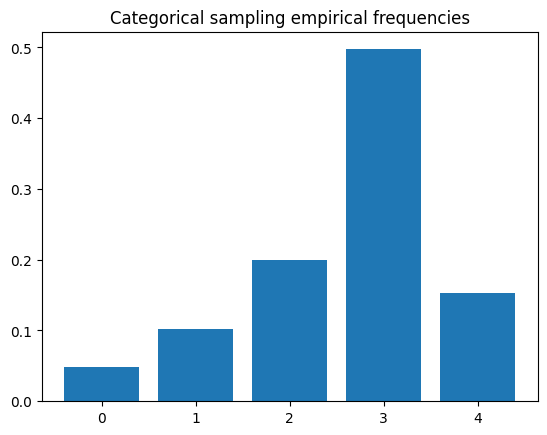

In [9]:
# ============================================================
# I: Categorical sampling (sampling according to discrete probability mass functions)
# ============================================================
def sample_categorical(probs: torch.Tensor, n: int):
    """
    Sample n indices from a categorical distribution.

    Args:
        probs: Tensor of shape (K,). Nonnegative and sums to 1 (a PMF).
        n: Number of samples to draw.

    Returns:
        idx: LongTensor of shape (n,), with values in {0, 1, ..., K-1}.
    """
    # TODO:
    # 1) (Optional but recommended) normalize probs so it sums to 1 (numerical safety).
    # 2) Use torch.multinomial to draw n samples WITH replacement.
    #    Hint: torch.multinomial(probs, num_samples=n, replacement=True)
    
    idx = 
    return idx

# Demo
K = 5
probs = torch.tensor([0.05, 0.10, 0.20, 0.50, 0.15], device=device)
idx = sample_categorical(probs, n=20000)
counts = torch.bincount(idx, minlength=K).float() / idx.numel()
print("Target probs: ", probs.detach().cpu().numpy())
print("Empirical:    ", counts.detach().cpu().numpy())

plt.figure()
plt.bar(range(K), counts.detach().cpu().numpy())
plt.title("Categorical sampling empirical frequencies")
plt.show()

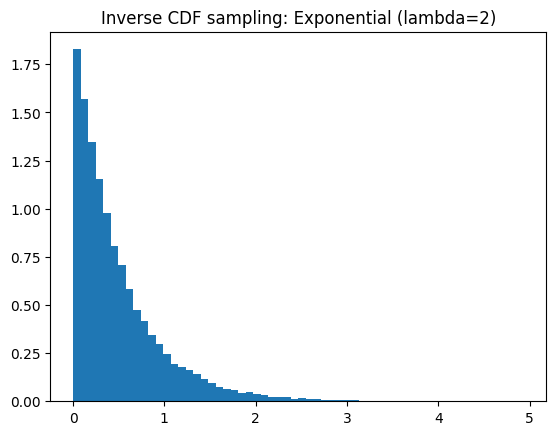

In [5]:
# ============================================================
# II: Inverse CDF sampling (Exponential)
# ============================================================
def sample_exponential(n: int, lam: float = 2.0):
    """
    Exponential with pdf p(x)=lam*exp(-lam x), x>=0
    Using inverse CDF: x = -(1/lam) log(1-u), u~U(0,1)
    """
    u = torch.rand(n, device=device)
    # TODO: implement inverse CDF sampling
    x = 
    return x

x_exp = sample_exponential(20000, lam=2.0)
hist_plot(x_exp, "Inverse CDF sampling: Exponential (lambda=2)")

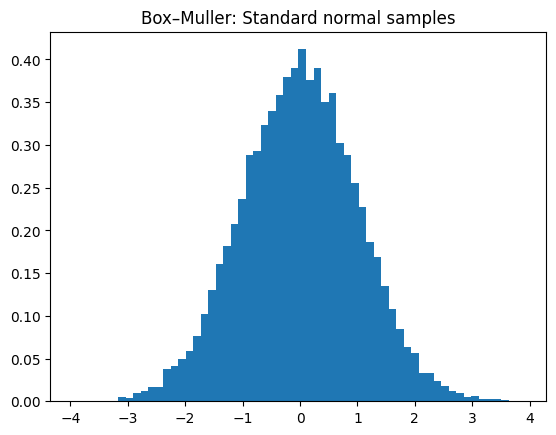

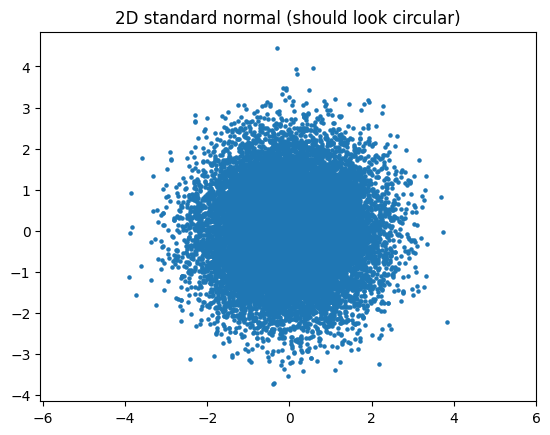

In [10]:
# ============================================================
# III: Box–Muller (Gaussian from uniforms)
# ============================================================
def sample_standard_normal_box_muller(n: int):
    """
    Sample n i.i.d. values from N(0,1) using the Box–Muller transform.

    Idea:
      1) Sample u1, u2 ~ Uniform(0,1)
      2) Transform to polar coords:
           r = sqrt(-2 log u1),  theta = 2 pi u2
      3) Convert to Cartesian:
           z1 = r cos(theta), z2 = r sin(theta)
      4) Return n values (handle odd n by generating pairs)

    Returns:
        z: Tensor of shape (n,) on 'device'
    """
    # TODO:
    # 1) Let m = ceil(n/2) be the number of (u1,u2) pairs to generate.
    # 2) Sample u1, u2 ~ U(0,1) with shape (m,).
    # 3) Clamp u1 away from 0 before taking log (e.g., clamp_min(1e-12)).
    # 4) Compute r and theta as above.
    # 5) Compute z1, z2 and concatenate them, then truncate to length n.

    z = 
    return z

z = sample_standard_normal_box_muller(20000)
hist_plot(z, "Box–Muller: Standard normal samples")

# 2D Gaussian via Box–Muller pairs
z2d = torch.stack([
    sample_standard_normal_box_muller(20000),
    sample_standard_normal_box_muller(20000)
], dim=1)
scatter_plot(z2d, "2D standard normal (should look circular)")

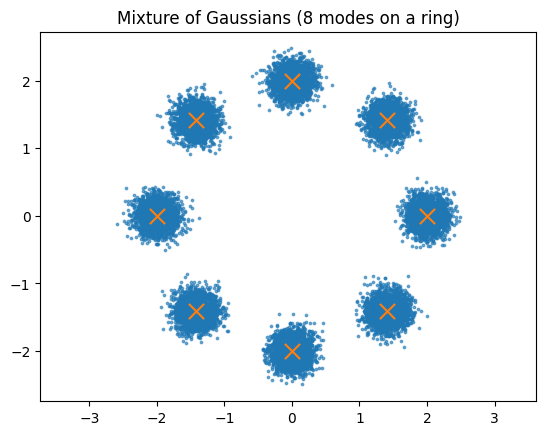

In [11]:
# ============================================================
# IV: Mixture of Gaussians in 2D (8 modes on a ring)
# Sampling procedure:
#   1) sample component k ~ Categorical(pi)
#   2) sample x ~ N(mu_k, sigma^2 I)
# ============================================================
def make_ring_centers(K=8, radius=2.0):
    """
    Create K 2D centers equally spaced on a circle of given radius.

    Returns:
        centers: Tensor of shape (K, 2)
    """
    angles = torch.arange(K, device=device) * (2.0 * math.pi / K)
    centers = torch.stack([radius * torch.cos(angles),
                           radius * torch.sin(angles)], dim=1)  # (K,2)
    return centers

def sample_mixture_of_gaussians(n: int, centers: torch.Tensor, sigma: float, pi: torch.Tensor):
    """
    Sample from a 2D mixture of K isotropic Gaussians.

    Args:
        n: number of samples
        centers: (K,2) tensor of component means mu_k
        sigma: scalar std for each Gaussian component
        pi: (K,) mixture weights (PMF), should sum to 1

    Returns:
        x: (n,2) samples
        k: (n,) component indices in {0,...,K-1}
    """
    K = centers.shape[0]

    # TODO:
    # 1) Sample component indices k ~ Cat(pi) of shape (n,).
    # 2) Sample eps ~ N(0, I) of shape (n, 2).
    # 3) Gather the mean for each sample: mu = centers[k] (shape (n,2)).
    # 4) Return x = mu + sigma * eps, and the indices k.
    k = 
    x = 
    return x, k

# Setup mixture
K = 8
centers = make_ring_centers(K=K, radius=2.0)
pi = torch.ones(K, device=device) / K
sigma = 0.15

samples, comp = sample_mixture_of_gaussians(20000, centers, sigma, pi)

# Plot samples + centers
plt.figure()
xy = samples.detach().cpu()
plt.scatter(xy[:,0], xy[:,1], s=3, alpha=0.6)
cc = centers.detach().cpu()
plt.scatter(cc[:,0], cc[:,1], s=120, marker="x")
plt.title("Mixture of Gaussians (8 modes on a ring)")
plt.axis("equal")
plt.show()

In [8]:
# ============================================================
# V: Simple diversity diagnostic (mode coverage)
# ============================================================
@torch.no_grad()
def mode_coverage(samples: torch.Tensor, centers: torch.Tensor):
    """
    Assign each sample to nearest center; report how many modes got at least one sample.
    """
    # (N,1,2) - (1,K,2) -> (N,K,2) -> d2 (N,K)
    # N: number of samples
    # K: number of centres
    d2 = ((samples[:, None, :] - centers[None, :, :]) ** 2).sum(dim=2)
    idx = torch.argmin(d2, dim=1)  # (N,)
    counts = torch.bincount(idx, minlength=centers.shape[0]).float()
    covered = int((counts > 0).sum().item())
    freq = counts / counts.sum()
    return covered, freq

covered, freq = mode_coverage(samples, centers)
print(f"Modes covered: {covered}/{K}")
print("Mode frequencies:", freq.detach().cpu().numpy())

Modes covered: 8/8
Mode frequencies: [0.12225 0.1284  0.12925 0.12145 0.12535 0.1233  0.12455 0.12545]
